In [70]:
import numpy as np 
import pandas as pd 
import random
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.layers import TextVectorization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

In [71]:
DataSetListingPath = '/kaggle/input/datasets/organizations/airbnb/seattle/listings.csv'
DataSetReviewsPath = '/kaggle/input/datasets/organizations/airbnb/seattle/reviews.csv'
df_reviews = pd.read_csv(DataSetReviewsPath)
df_listings = pd.read_csv(DataSetListingPath)

In [72]:
df_reviews.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,7202016,38917982,2015-07-19,28943674,Bianca,Cute and cozy place. Perfect location to every...
1,7202016,39087409,2015-07-20,32440555,Frank,Kelly has a great room in a very central locat...
2,7202016,39820030,2015-07-26,37722850,Ian,"Very spacious apartment, and in a great neighb..."
3,7202016,40813543,2015-08-02,33671805,George,Close to Seattle Center and all it has to offe...
4,7202016,41986501,2015-08-10,34959538,Ming,Kelly was a great host and very accommodating ...


In [73]:
df_reviews.shape

(84849, 6)

In [74]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 84849 entries, 0 to 84848
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   listing_id     84849 non-null  int64 
 1   id             84849 non-null  int64 
 2   date           84849 non-null  object
 3   reviewer_id    84849 non-null  int64 
 4   reviewer_name  84849 non-null  object
 5   comments       84831 non-null  object
dtypes: int64(3), object(3)
memory usage: 3.9+ MB


In [75]:
df_reviews['listing_id'].nunique()

3191

In [76]:
listings_subset = df_listings[['id', 'review_scores_rating']].copy()
reviews_subset = df_reviews[['listing_id', 'comments']].copy()

In [77]:
listings_subset.isnull().sum()

id                        0
review_scores_rating    647
dtype: int64

In [78]:
median_rating = listings_subset['review_scores_rating'].median()
listings_subset['review_scores_rating'] = listings_subset['review_scores_rating'].fillna(median_rating)

listings_subset.isnull().sum()


id                      0
review_scores_rating    0
dtype: int64

In [79]:
reviews_subset.isnull().sum()
reviews_subset = reviews_subset.dropna(subset=['comments'])
reviews_subset.isnull().sum()

listing_id    0
comments      0
dtype: int64

In [80]:
df_merged = pd.merge(
    reviews_subset, 
    listings_subset, 
    left_on='listing_id', 
    right_on='id', 
    how='inner'
)

In [81]:
df_merged.head()
df_merged = df_merged.drop(columns=['id','listing_id'])
df_merged.shape

(84831, 2)

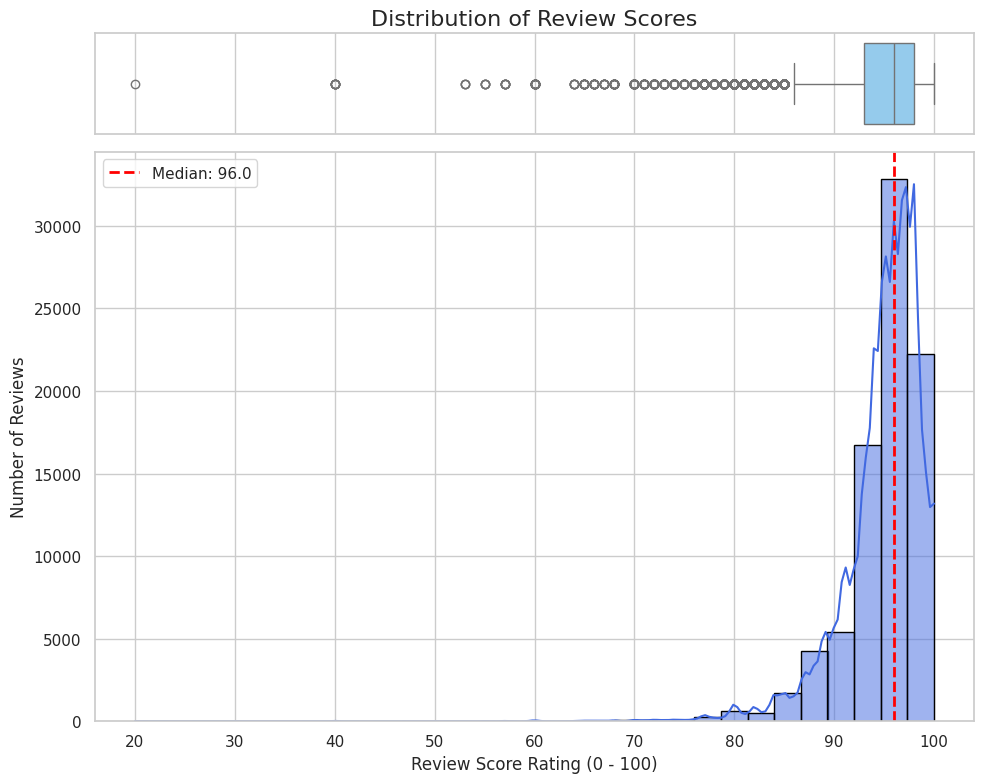

--- Score Statistics ---
count    84831.000000
mean        94.896783
std          4.084441
min         20.000000
25%         93.000000
50%         96.000000
75%         98.000000
max        100.000000
Name: review_scores_rating, dtype: float64
Scores strictly less than 95: 29725 (35.04%)
Scores 95 and greater:      55106 (64.96%)


In [82]:
sns.set_theme(style="whitegrid")

# Create a figure with two subplots (Histogram on top, Boxplot on bottom)
fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, figsize=(10, 8), gridspec_kw={"height_ratios": (.15, .85)})

# 1. Top Subplot: Boxplot (Great for spotting outliers)
sns.boxplot(x=df_merged['review_scores_rating'], ax=ax_box, color='lightskyblue')
ax_box.set(xlabel='') # Hide the x-label for the top plot
ax_box.set_title('Distribution of Review Scores', fontsize=16)

# 2. Bottom Subplot: Histogram with KDE (Density curve)
sns.histplot(df_merged['review_scores_rating'], bins=30, kde=True, ax=ax_hist, color='royalblue', edgecolor='black')
ax_hist.set_xlabel('Review Score Rating (0 - 100)', fontsize=12)
ax_hist.set_ylabel('Number of Reviews', fontsize=12)

# Add a vertical line showing the median score
median_score = df_merged['review_scores_rating'].median()
ax_hist.axvline(median_score, color='red', linestyle='--', linewidth=2, label=f'Median: {median_score}')
ax_hist.legend()

plt.tight_layout()
plt.show()

# Print some quick summary statistics
print("--- Score Statistics ---")
print(df_merged['review_scores_rating'].describe())
below_95 = (df_merged['review_scores_rating'] < 95).sum()
above_or_equal_95 = (df_merged['review_scores_rating'] >= 95).sum()

# Calculate the percentages for context
total_reviews = len(df_merged)
percent_below = (below_95 / total_reviews) * 100
percent_above = (above_or_equal_95 / total_reviews) * 100

print(f"Scores strictly less than 95: {below_95} ({percent_below:.2f}%)")
print(f"Scores 95 and greater:      {above_or_equal_95} ({percent_above:.2f}%)")



In [83]:
df_merged['sentiment_label'] = (df_merged['review_scores_rating'] >= 95).astype(int)

df_merged = df_merged.drop(columns=['review_scores_rating'])

print(df_merged.head())

                                            comments  sentiment_label
0  Cute and cozy place. Perfect location to every...                1
1  Kelly has a great room in a very central locat...                1
2  Very spacious apartment, and in a great neighb...                1
3  Close to Seattle Center and all it has to offe...                1
4  Kelly was a great host and very accommodating ...                1


In [84]:
def clean_text(text):
    text = re.sub(r"http\S+", "", text)  
    text = re.sub(r"@\w+", "", text)     
    text = re.sub(r"#\w+", "", text)     
    text = re.sub(r"[^\w\s.,!?]", "", text)  
    return text

df_merged["comments"] = df_merged["comments"].apply(clean_text)
df_merged.head()

,comments,sentiment_label
0,Cute and cozy place. Perfect location to every...,1
1,Kelly has a great room in a very central locat...,1
2,"Very spacious apartment, and in a great neighb...",1
3,Close to Seattle Center and all it has to offe...,1
4,Kelly was a great host and very accommodating ...,1


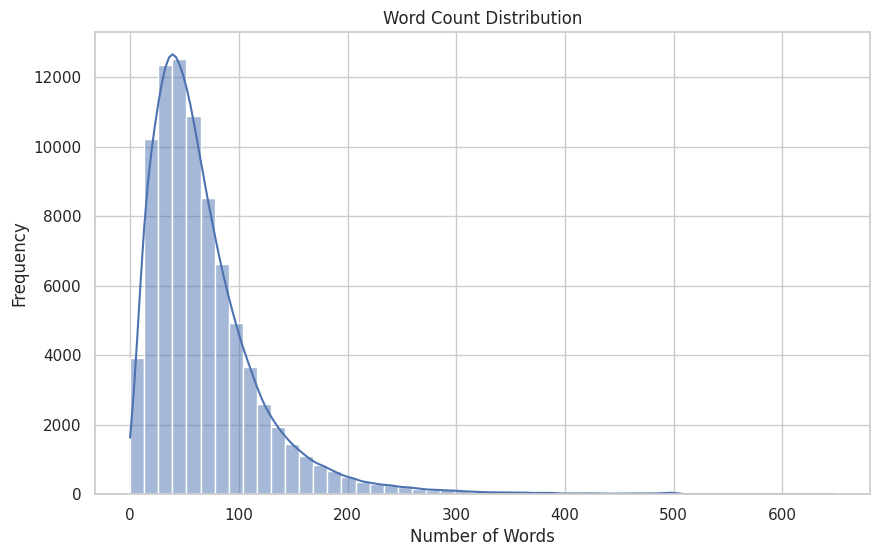

90%: 130.0
95%: 167.0
99%: 271.0


In [85]:
df_merged["word_count"] = df_merged["comments"].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.histplot(df_merged["word_count"], bins=50, kde=True)

plt.title("Word Count Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

print("90%:", df_merged["word_count"].quantile(0.90))
print("95%:", df_merged["word_count"].quantile(0.95))
print("99%:", df_merged["word_count"].quantile(0.99))

In [86]:
df_merged.drop(columns=["word_count"], inplace=True)
df_merged.head()

,comments,sentiment_label
0,Cute and cozy place. Perfect location to every...,1
1,Kelly has a great room in a very central locat...,1
2,"Very spacious apartment, and in a great neighb...",1
3,Close to Seattle Center and all it has to offe...,1
4,Kelly was a great host and very accommodating ...,1


In [87]:
df_majority = df_merged[df_merged.sentiment_label == 1] 
df_minority = df_merged[df_merged.sentiment_label == 0]

# Downsample the majority class to match the minority class size
df_majority_downsampled = resample(
    df_majority, 
    replace=False, 
    n_samples=len(df_minority), 
    random_state=42
)

df_balanced = pd.concat([df_majority_downsampled, df_minority]).sample(frac=1).reset_index(drop=True)

In [88]:
print("Balanced Class Counts:")
print(df_balanced.sentiment_label.value_counts())

Balanced Class Counts:
sentiment_label
0    29725
1    29725
Name: count, dtype: int64


In [89]:

X = df_balanced['comments'].values
y = df_balanced['sentiment_label'].values

X_train_val, X_test, y_train_val, y_test = train_test_split(
    df_balanced['comments'], 
    df_balanced['sentiment_label'], 
    test_size=0.15, 
    random_state=42, 
    stratify=df_balanced['sentiment_label'] # Ensures balance is kept in the split
)


X_train, X_val, y_train, y_test_val = train_test_split(
    X_train_val, 
    y_train_val, 
    test_size=0.15, 
    random_state=42,
    stratify=y_train_val
)


X_train_np = np.array(X_train, dtype=object)
X_val_np = np.array(X_val, dtype=object)
X_test_np = np.array(X_test, dtype=object)

y_train_np = y_train.values.astype(np.float32)
y_val_np = y_test_val.values.astype(np.float32)
y_test_np = y_test.values.astype(np.float32)

In [90]:
max_vocab_size = 20000  
max_sequence_length = 200
embedding_dim = 128

In [91]:
vectorizer = TextVectorization(
    max_tokens=max_vocab_size,
    output_mode='int',
    output_sequence_length=max_sequence_length
)

In [92]:
vectorizer.adapt(X_train_np)

In [93]:
model = Sequential([
    
    tf.keras.Input(shape=(1,), dtype=tf.string),
    vectorizer,
    
    
    Embedding(input_dim=max_vocab_size, output_dim=embedding_dim, mask_zero=False),
    
   
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    
   
    Dense(32, activation='relu'),
    Dropout(0.5),
    
   
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [99]:
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath='best_bilstm_weights.keras',
    monitor='val_loss',                   
    save_best_only=True,                  
    mode='min'                           
)
history = model.fit(
    X_train_np, y_train_np,
    epochs=15,
    batch_size=64,
    validation_data=(X_val_np, y_val_np), 
    callbacks=[early_stop, checkpoint_cb]
)

Epoch 1/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8480 - loss: 0.3227 - val_accuracy: 0.7590 - val_loss: 0.5199
Epoch 2/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8602 - loss: 0.2933 - val_accuracy: 0.7574 - val_loss: 0.5409
Epoch 3/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8702 - loss: 0.2651 - val_accuracy: 0.7524 - val_loss: 0.5757
Epoch 4/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.8770 - loss: 0.2553 - val_accuracy: 0.7491 - val_loss: 0.6585
Epoch 5/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8862 - loss: 0.2358 - val_accuracy: 0.7468 - val_loss: 0.6355
Epoch 6/15
672/672 ━━━━━━━━━━━━━━━━━━━━ 13s 20ms/step - accuracy: 0.8808 - loss: 0.2358 - val_accuracy: 0.7468 - val_loss: 0.8100


In [100]:
y_pred_probs = model.predict(X_test_np)
y_pred_classes = (y_pred_probs > 0.5).astype("int32")

print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred_classes, target_names=["Needs Improvement (0)", "Positive (1)"]))

279/279 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

--- Classification Report ---
                       precision    recall  f1-score   support

Needs Improvement (0)       0.74      0.83      0.78      4459
         Positive (1)       0.81      0.71      0.76      4459

             accuracy                           0.77      8918
            macro avg       0.77      0.77      0.77      8918
         weighted avg       0.77      0.77      0.77      8918



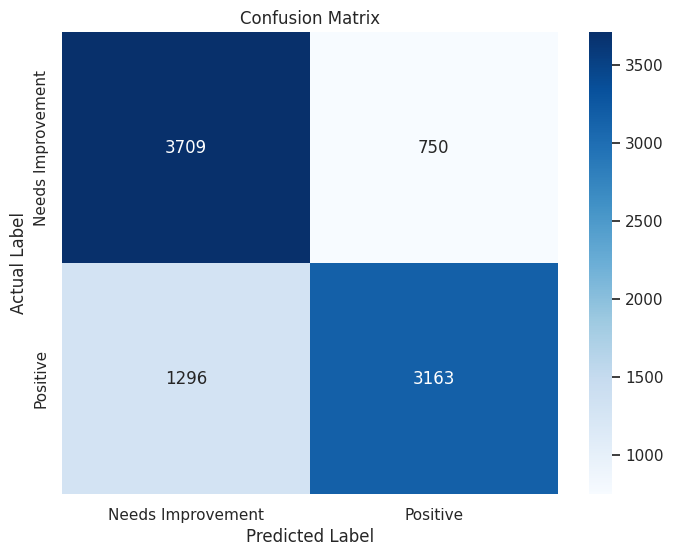

In [101]:
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Needs Improvement", "Positive"], 
            yticklabels=["Needs Improvement", "Positive"],)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

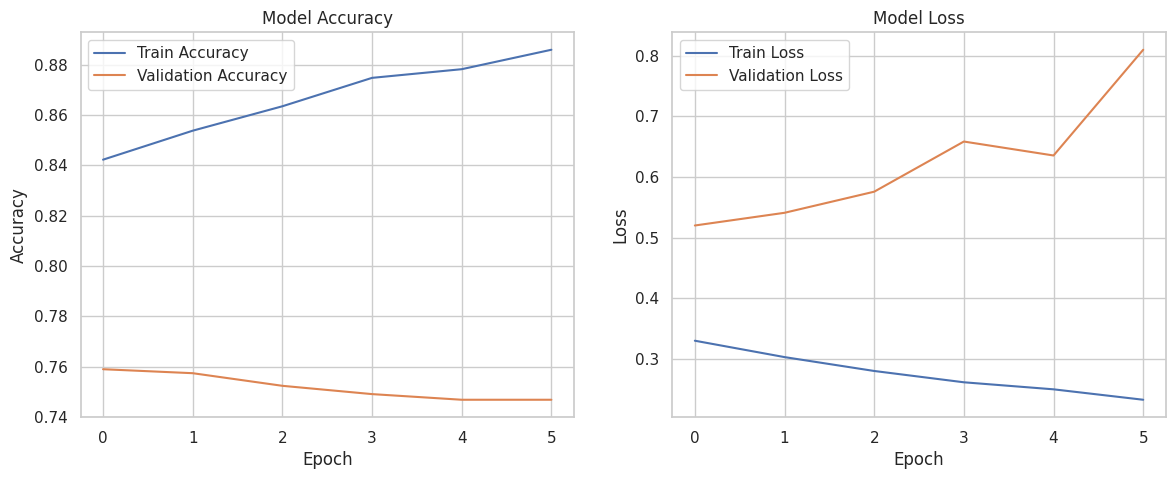

In [102]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_training_history(history)